## 1. Setup

Configuración y rutas del dataset.

In [5]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
REPO = Path.cwd()
raw_dir = REPO / "data" / "raw"
dataset_root = raw_dir / "chest_xray"
if not dataset_root.exists():
    dataset_root = raw_dir
processed_dir = REPO / "data" / "processed"
models_dir = REPO / "models"
models_dir.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.15  # 15% de train para validación (no usamos la carpeta val)

print(f"Dataset root: {dataset_root} (exists: {dataset_root.exists()})")

Dataset root: /home/emilio/Desktop/TESIS/data/raw/chest_xray (exists: True)


## 2. Data augmentation (train) y preprocesado base

- **Train**: flip horizontal, rotación y zoom suave para regularizar.
- **Val/Test**: solo resize + normalización [0, 1].

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode="nearest",
    validation_split=VAL_SPLIT,
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=VAL_SPLIT)

## 3. Generadores por split

No se usa la carpeta `val` (muy pocos datos). Se toma un **% de train** como validación con `validation_split` + `subset`. Clases: `NORMAL` (0), `PNEUMONIA` (1). `class_mode='binary'` para clasificación binaria.

In [8]:
def make_generator(datagen, split, shuffle=True, subset=None):
    kwargs = dict(
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=shuffle,
        seed=SEED,
    )
    if subset is not None:
        kwargs["subset"] = subset
    return datagen.flow_from_directory(dataset_root / split, **kwargs)

# Train y val salen de la misma carpeta "train"; test sigue siendo la carpeta "test"
train_ds = make_generator(train_datagen, "train", shuffle=True, subset="training")
val_ds = make_generator(val_test_datagen, "train", shuffle=False, subset="validation")
test_ds = make_generator(val_test_datagen, "test", shuffle=False)

print("Class indices:", train_ds.class_indices)
print("Train batches:", len(train_ds), "| Val:", len(val_ds), "| Test:", len(test_ds))

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches: 139 | Val: 25 | Test: 20


## 4. Verificación visual (opcional)

Mostrar un batch de train para comprobar preprocesado y etiquetas.

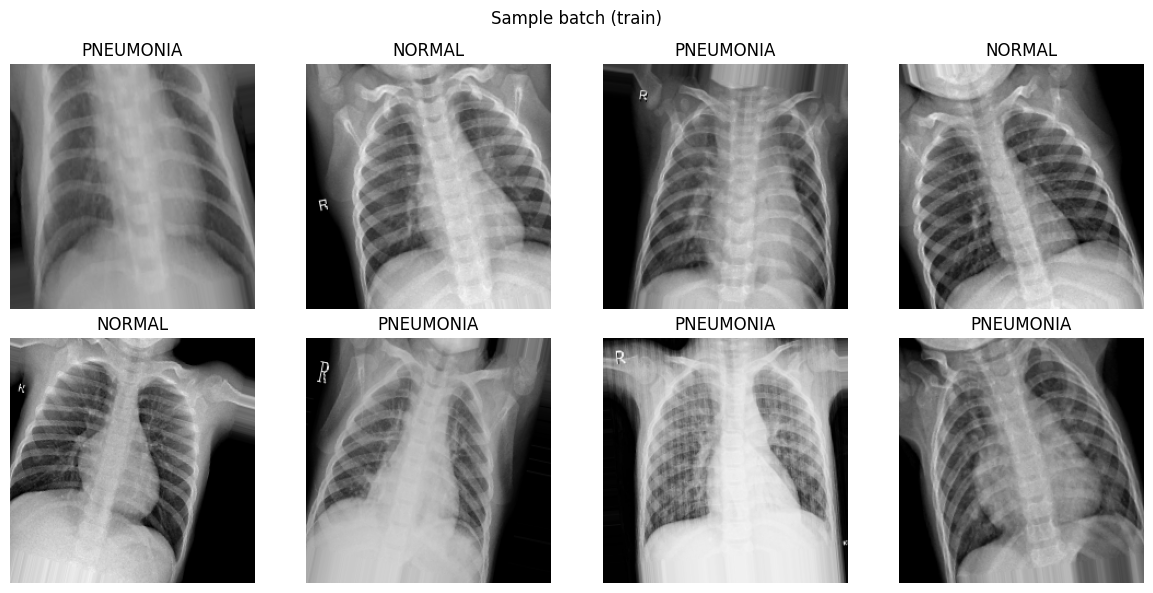

In [9]:
import matplotlib.pyplot as plt

batch_x, batch_y = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(batch_x[i])
    ax.set_title("PNEUMONIA" if batch_y[i] == 1 else "NORMAL")
    ax.axis("off")
plt.suptitle("Sample batch (train)")
plt.tight_layout()
plt.show()